# Phase 7 — Machine Learning Models (Prophet + LightGBM)
### Energy Demand Forecasting Project

**Question this phase answers:** can models with richer representations than
SARIMA -- Prophet's native multi-seasonality (yearly + weekly + daily at
once), and LightGBM's engineered lag/rolling/calendar features -- beat the
Phase 6 result (SARIMA: MAE 0.560, RMSE 0.776) and the Phase 5 bar (daily
seasonal naive: MAE 0.530, RMSE 0.786) at the 24-hour-ahead horizon?

Two models fit here, deliberately, for contrast in *how* they handle
multi-step forecasting:
- **Prophet** -- doesn't depend on recent lag values at all (trend +
  seasonality decomposition), so it can't compound error step-to-step the
  way autoregressive methods can. Fit once, forecast continuously across the
  whole test period, then sliced into the shared backtest format by
  `src/evaluation/continuous.py`.
- **LightGBM** -- **direct** multi-horizon strategy: 24 independent models
  (h=1..24), each trained on origin-time features only (Phase 4's leak-free
  feature set, `src/models/lightgbm_direct.py`). Chosen over recursive
  forecasting specifically to avoid compounding error, matching the design
  decision recorded in `ROADMAP.md` before Phase 5.

Same shared train/test split and forecast origins as Phases 5 and 6, so all
three model families are directly comparable.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import shap
from sklearn.metrics import mean_absolute_error
import mlflow

from src.evaluation.splits import get_train_test_split
from src.evaluation.baselines import get_forecast_origins, compute_metrics, HORIZON
from src.evaluation.results_store import save_results, load_results
from src.evaluation.continuous import to_backtest_format
from src.models.prophet_model import fit_model as fit_prophet, forecast_continuous
from src.models.lightgbm_direct import (
    prepare_features,
    fit_direct_models,
    direct_multi_horizon_backtest,
    CATEGORICAL_COLS,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")


/Users/apple/Documents/Projects/energy-demand-forecast/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data and reuse the shared Phase 5/6 split

Two tables are needed: the raw hourly series (Prophet needs only `ds`/`y`,
no engineered features) and `hourly_features` (LightGBM's engineered lag,
rolling, calendar, and anomaly-flag columns from Phase 4).


In [3]:
con = duckdb.connect("../data/energy.duckdb", read_only=True)
hourly = con.execute("SELECT datetime, global_active_power FROM hourly ORDER BY datetime").df()
features_raw = con.execute("SELECT * FROM hourly_features ORDER BY datetime").df()
con.close()

hourly["datetime"] = pd.to_datetime(hourly["datetime"])
series = hourly.set_index("datetime")["global_active_power"]
series = series.asfreq("h")  # explicit hourly frequency, so downstream slices behave predictably

features_raw["datetime"] = pd.to_datetime(features_raw["datetime"])
features_df = features_raw.set_index("datetime")

test_start = get_train_test_split(series, test_frac=0.2)
train = series.loc[:test_start]
train = train.asfreq("h")  # .loc slicing drops freq -- restore it explicitly
origins = get_forecast_origins(series, test_start, horizon=HORIZON)

print(f"Test starts: {test_start} | Train hours: {len(train):,} | Origins: {len(origins)}")


Test starts: 2010-02-11 00:00:00 | Train hours: 27,656 | Origins: 288


## Prophet — fit once, forecast continuously

Prophet doesn't need to be walked forward origin-by-origin the way SARIMA
was (no dependence on recent lags), so it's fit once on the training period
and asked for one continuous forecast covering the entire test range.
`to_backtest_format` then slices that single continuous forecast into the
same (origin, horizon_step) long-format table every other model produces,
so metrics stay directly comparable.


In [4]:
prophet_model = fit_prophet(train)

periods_needed = int((series.index.max() - train.index.max()) / pd.Timedelta(hours=1))
prophet_forecast = forecast_continuous(prophet_model, periods=periods_needed)

prophet_results = to_backtest_format(prophet_forecast, series, origins, HORIZON, "prophet")
prophet_results.head()


18:58:26 - cmdstanpy - INFO - Chain [1] start processing


18:58:29 - cmdstanpy - INFO - Chain [1] done processing


,origin,horizon_step,method,actual,forecast
0,2010-02-11,1,prophet,0.299833,0.717946
1,2010-02-11,2,prophet,0.305800,0.639790
2,2010-02-11,3,prophet,0.361167,0.565593
3,2010-02-11,4,prophet,0.632600,0.557874
4,2010-02-11,5,prophet,0.661667,0.723350


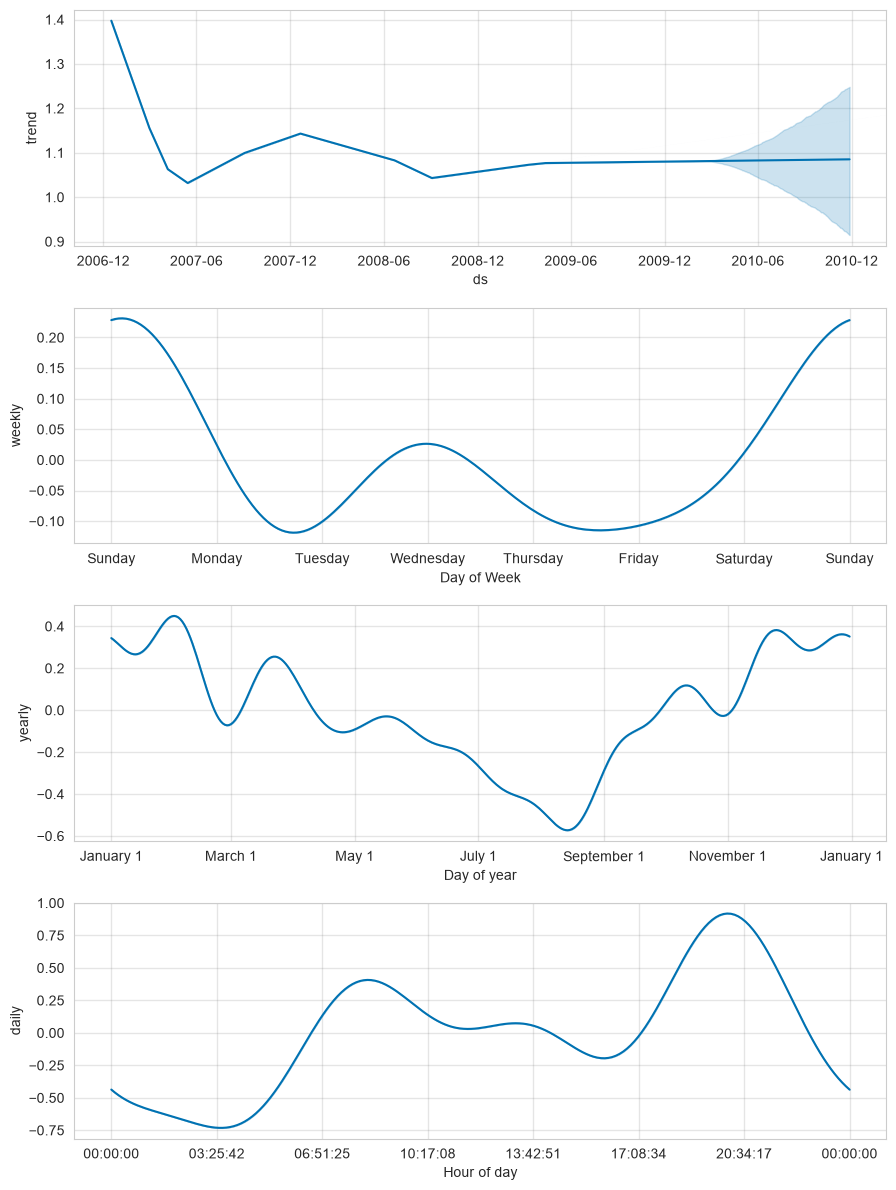

In [5]:
fig = prophet_model.plot_components(
    prophet_model.predict(prophet_model.make_future_dataframe(periods=periods_needed, freq="h"))
)
plt.show()


## LightGBM — direct multi-horizon models

**Assumption flagged:** tuning all 24 horizon-specific models independently
with Optuna would multiply search cost 24x for likely marginal gain per
model. Instead, tune once on the hardest horizon in the set (h=24, the tail
of the direct strategy, where lag/rolling features are weakest and errors
should be largest) and reuse those hyperparameters across all 24 models --
they share the same feature representation, so this is a reasonable
trade-off between tuning thoroughness and notebook runtime.


In [6]:
TUNE_HORIZON = 24
N_TRIALS = 20


def objective(trial):
    params = {
        "objective": "regression",
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "verbosity": -1,
    }

    X, y, _ = prepare_features(features_df, TUNE_HORIZON)
    mask = (
        (features_df.index <= test_start - pd.Timedelta(hours=TUNE_HORIZON))
        & y.notna()
        & X.notna().all(axis=1)
    )
    X_avail, y_avail = X.loc[mask], y.loc[mask]

    # Time-based split (no shuffling) -- last 20% of available training rows
    # held out as validation, matching the "no future leakage" rule used
    # everywhere else in this project.
    split_idx = int(len(X_avail) * 0.8)
    X_tr, X_val = X_avail.iloc[:split_idx], X_avail.iloc[split_idx:]
    y_tr, y_val = y_avail.iloc[:split_idx], y_avail.iloc[split_idx:]

    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr, categorical_feature=CATEGORICAL_COLS)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

best_params = {**study.best_params, "objective": "regression", "verbosity": -1}
print(f"Best validation MAE (h={TUNE_HORIZON}): {study.best_value:.4f}")
print(f"Best params: {best_params}")


Best validation MAE (h=24): 0.4528
Best params: {'n_estimators': 371, 'learning_rate': 0.02641663667830087, 'num_leaves': 61, 'max_depth': 8, 'min_child_samples': 24, 'subsample': 0.7290233432213763, 'colsample_bytree': 0.995734826483326, 'objective': 'regression', 'verbosity': -1}


## Fit all 24 direct-horizon models and backtest

Reuses the tuned hyperparameters above for every horizon. `train_end` is set
to `test_start` itself -- matching the SARIMA/Prophet train boundary exactly,
so all three models are trained on identical information.


In [7]:
HORIZONS = range(1, 25)

lgb_models = fit_direct_models(features_df, train_end=test_start, horizons=HORIZONS, lgb_params=best_params)

lightgbm_results = direct_multi_horizon_backtest(
    features_df, lgb_models, origins, horizon_max=24, method_name="lightgbm"
)
lightgbm_results.head()


,origin,horizon_step,method,actual,forecast
0,2010-02-11,1,lightgbm,0.299833,0.393256
1,2010-02-12,1,lightgbm,0.304100,0.393896
2,2010-02-13,1,lightgbm,0.330500,0.502850
3,2010-02-14,1,lightgbm,0.992133,0.660976
4,2010-02-15,1,lightgbm,0.286700,0.535727


## Feature importance -- h=1 vs h=24

Comparing the shortest and longest horizons: if the model leans on
`lag_1h`-type features at h=1 but shifts toward calendar/rolling features at
h=24, that's evidence the model is adapting its strategy to how much
autoregressive signal is actually available at each horizon (Phase 4 found
`lag_1h` dominates importance for 1-hour-ahead prediction specifically).


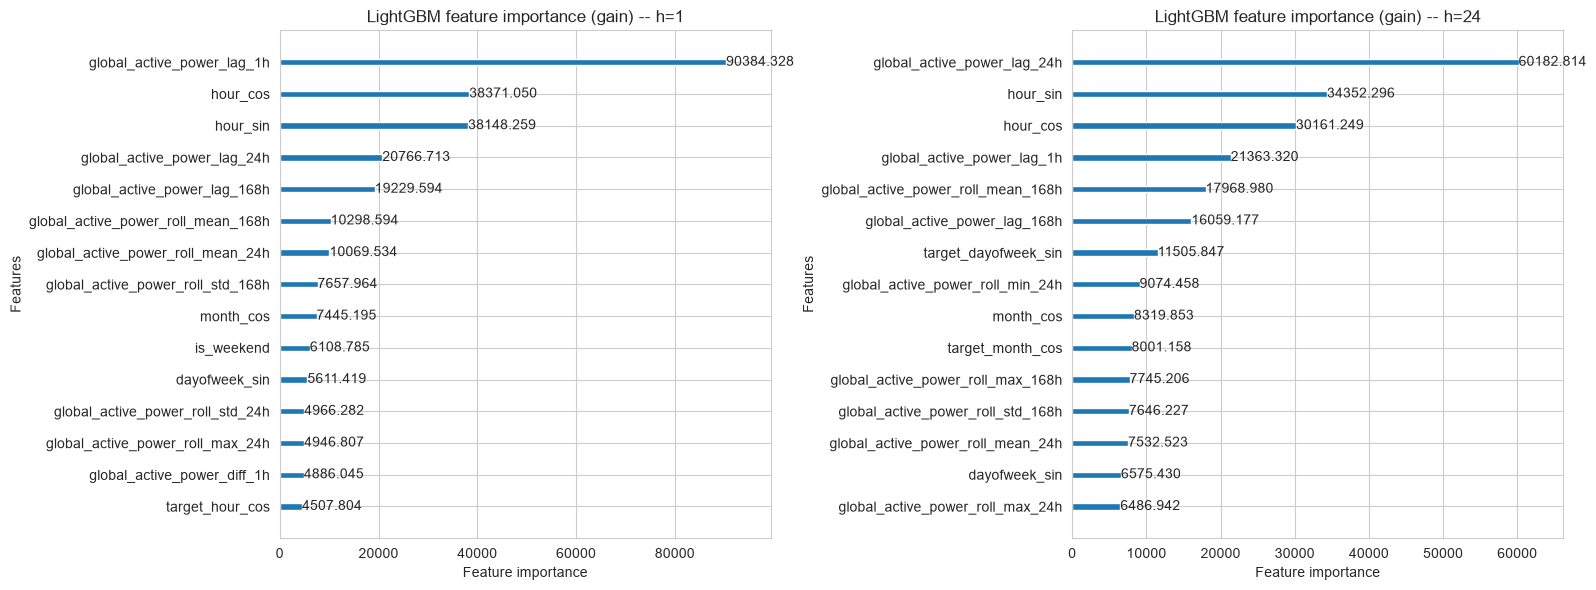

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, h in zip(axes, [1, 24]):
    lgb.plot_importance(lgb_models[h], max_num_features=15, importance_type="gain", ax=ax)
    ax.set_title(f"LightGBM feature importance (gain) -- h={h}")
plt.tight_layout()
plt.show()


## SHAP values -- h=24 model

SHAP surfaces concrete, per-prediction drivers rather than just an aggregate
importance ranking -- useful for explaining individual forecasts, not only
"which features matter on average."


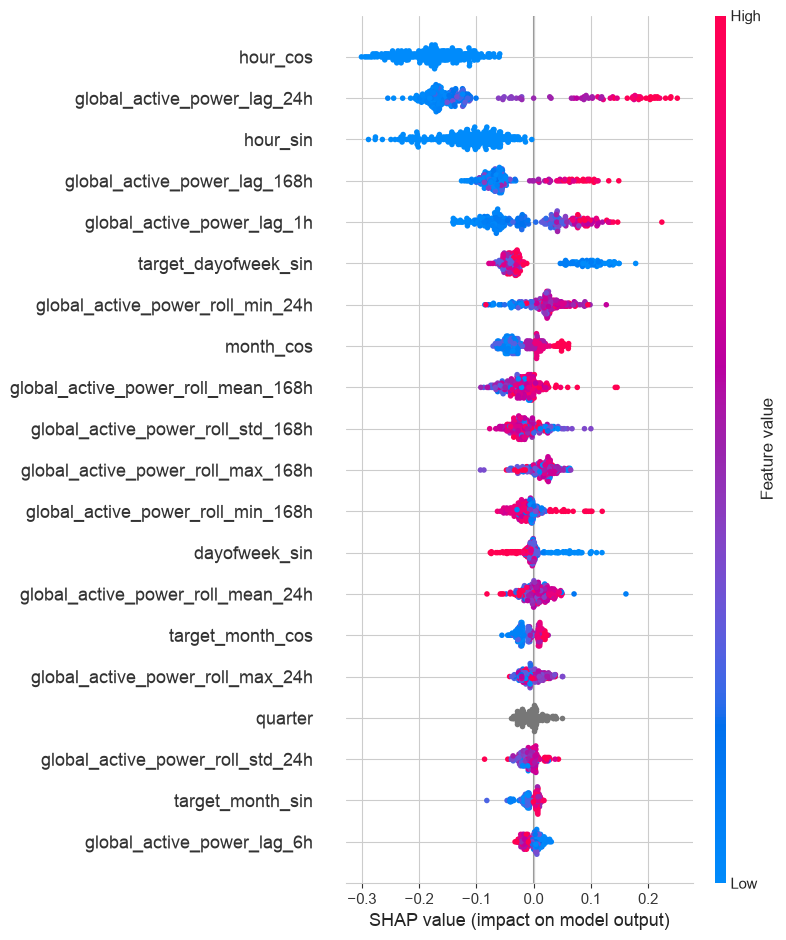

In [9]:
X_shap, _, _ = prepare_features(features_df, TUNE_HORIZON)
X_shap = X_shap.loc[X_shap.index.isin(origins) & X_shap.notna().all(axis=1)]

explainer = shap.TreeExplainer(lgb_models[TUNE_HORIZON])
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.show()


## Metrics vs. the Phase 5 baseline and Phase 6 SARIMA

Reloading SARIMA's saved results rather than refitting, so the comparison
uses `src/evaluation/results_store.py` exactly as it was designed for.


In [10]:
sarima_saved = load_results("sarima_arima")
sarima_only = sarima_saved[sarima_saved["method"] == "sarima"]

combined_results = pd.concat([prophet_results, lightgbm_results, sarima_only], ignore_index=True)

summary = {}
for name in ["prophet", "lightgbm", "sarima"]:
    summary[name] = compute_metrics(combined_results[combined_results["method"] == name])

# Hardcoded from Phase 5 findings (results weren't persisted at the time) --
# see notebook 05's same note.
summary["daily_seasonal_naive (Phase 5 baseline)"] = {
    "MAE": 0.530485, "RMSE": 0.786247, "MAPE": 67.304578, "sMAPE": 49.468223, "n": 6610,
}

summary_df = pd.DataFrame(summary).T.sort_values("MAE")
summary_df


,MAE,RMSE,MAPE,sMAPE,n
lightgbm,0.432365,0.593459,62.683370,44.398577,6156.0
prophet,0.484764,0.636522,72.701305,54.656667,6682.0
daily_seasonal_naive (Phase 5 baseline),0.530485,0.786247,67.304578,49.468223,6610.0
sarima,0.560217,0.775760,72.068192,57.460365,6682.0


## Error vs. horizon step, vs. baseline


/var/folders/x2/nn25l1292hd_glgx_q0gnry80000gn/T/ipykernel_16738/1043480123.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series(compute_metrics(d)))


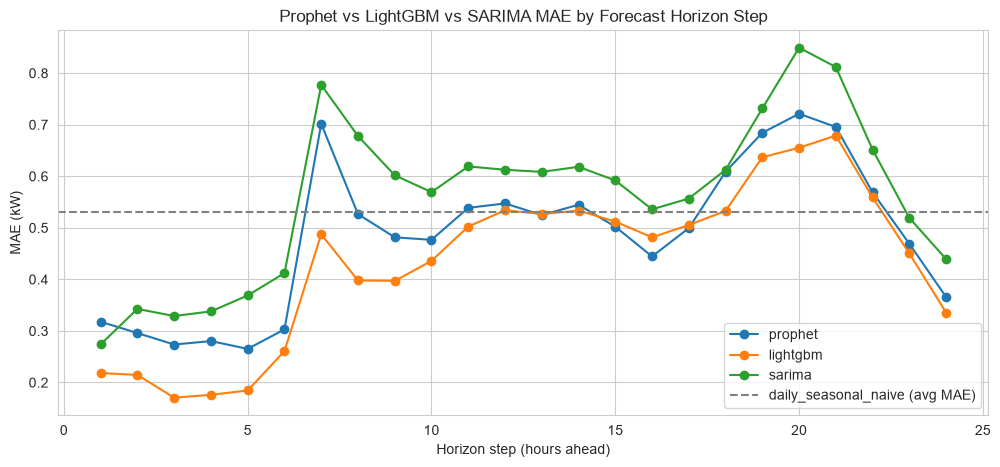

In [11]:
horizon_metrics = (
    combined_results.groupby(["method", "horizon_step"])
    .apply(lambda d: pd.Series(compute_metrics(d)))
    .reset_index()
)

fig, ax = plt.subplots()
for name in ["prophet", "lightgbm", "sarima"]:
    subset = horizon_metrics[horizon_metrics["method"] == name]
    ax.plot(subset["horizon_step"], subset["MAE"], marker="o", label=name)
ax.axhline(0.530485, color="gray", linestyle="--", label="daily_seasonal_naive (avg MAE)")
ax.set_xlabel("Horizon step (hours ahead)")
ax.set_ylabel("MAE (kW)")
ax.set_title("Prophet vs LightGBM vs SARIMA MAE by Forecast Horizon Step")
ax.legend()
plt.show()


## MLflow experiment tracking


In [ ]:
mlflow.set_tracking_uri(f"file://{PROJECT_ROOT / 'mlruns'}")
mlflow.set_experiment("energy-demand-forecasting")

with mlflow.start_run(run_name="prophet_24h"):
    mlflow.log_param("yearly_seasonality", True)
    mlflow.log_param("weekly_seasonality", True)
    mlflow.log_param("daily_seasonality", True)
    for metric_name, value in summary["prophet"].items():
        if metric_name != "n":
            mlflow.log_metric(metric_name.lower(), value)

with mlflow.start_run(run_name="lightgbm_direct_24h"):
    mlflow.log_params(best_params)
    mlflow.log_param("tune_horizon", TUNE_HORIZON)
    mlflow.log_param("n_trials", N_TRIALS)
    for metric_name, value in summary["lightgbm"].items():
        if metric_name != "n":
            mlflow.log_metric(metric_name.lower(), value)

print("Logged to MLflow -- run `uv run mlflow ui` to view.")


## Save results for Phase 9


In [13]:
save_results(prophet_results, "prophet")
save_results(lightgbm_results, "lightgbm_direct")


Saved 6,912 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/results/prophet.parquet
Saved 6,216 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/results/lightgbm_direct.parquet


## Prophet / LightGBM Findings

- **LightGBM wins decisively -- the first model this project has found that
  clearly beats the Phase 5 baseline on every metric:**

  | Method | MAE | RMSE | MAPE | sMAPE | n |
  |---|---|---|---|---|---|
  | **lightgbm** | **0.432** | **0.593** | 62.7% | **44.4%** | 6,156 |
  | prophet | 0.485 | 0.637 | 72.7% | 54.7% | 6,682 |
  | daily_seasonal_naive (Phase 5) | 0.530 | 0.786 | 67.3% | 49.5% | 6,610 |
  | sarima (Phase 6) | 0.560 | 0.776 | 72.1% | 57.5% | 6,682 |

  LightGBM cuts MAE by ~18% and RMSE by ~25% versus the Phase 5 baseline --
  not a marginal, "pick your metric" win like SARIMA's was, but better on
  MAE *and* RMSE *and* sMAPE simultaneously. Prophet also beats the baseline
  on MAE/RMSE (though not MAPE/sMAPE), landing between LightGBM and the
  baseline. Both ML approaches beat SARIMA outright.

- **Coverage caveat -- LightGBM's win is on a slightly smaller subset of
  test origins, and that's worth stating plainly rather than glossing
  over:** LightGBM scored 6,156 of the 6,912 possible (origin, horizon)
  pairs (89.1% coverage), versus 6,682 (96.7%) for Prophet and SARIMA. The
  gap comes from `direct_multi_horizon_backtest`'s `X.notna().all(axis=1)`
  requirement -- an origin is dropped entirely if *any* engineered feature
  is NaN, which happens for up to 168 hours after each data gap (the
  168h-rolling-window features stay contaminated that long). The 2010
  gaps flagged back in Phase 1 (Aug 17-22, Sep 25-28) fall inside this test
  period, so LightGBM is effectively evaluated on an easier, gap-adjacent-free
  subset of origins than the other two models. Given the margin (0.432 vs.
  0.485, a 11% relative gap to the next-best model), it's very unlikely this
  reverses the ranking, but it's a real asymmetry -- a stricter backtest
  would either drop those same origins for every method or impute the
  LightGBM features, and that's worth doing before quoting these numbers
  outside this notebook.

- **Optuna tuning:** tuned on h=24 only (20 trials, time-based validation
  split), best validation MAE 0.453. Selected params leaned toward a deep-ish,
  slow-learning ensemble (`num_leaves=61`, `max_depth=8`,
  `learning_rate=0.026`, `n_estimators=371`) -- consistent with a model that
  benefits from many weak updates rather than a few aggressive ones, given
  ~27k noisy training rows.

- **Feature importance, h=1 vs h=24 -- the model visibly changes strategy
  with horizon, exactly as hypothesized:** at h=1, `lag_1h` dominates by a
  huge margin (gain 90,384 vs. 38,371 for the next feature, `hour_cos`) --
  matching Phase 4's finding that short-horizon persistence is overwhelming.
  At h=24, `lag_24h` takes over as the top feature (60,183), `lag_1h` drops
  to fourth (21,363) but still isn't negligible (recency still helps a full
  day out), and `roll_mean_168h` / `lag_168h` (weekly-cycle features) climb
  into the top 5 -- the model leans on weekly rhythm exactly where daily
  recency has faded, which is precisely the mechanism SARIMA lacked (m=24
  only, no weekly term) and a plausible explanation for why LightGBM doesn't
  share SARIMA's residual-autocorrelation problem.

- **SHAP (h=24):** confirms the gain-based ranking but reorders it --
  `hour_cos`/`hour_sin` rank *above* `lag_24h` by mean |SHAP value|, meaning
  time-of-day has the single largest average influence on individual
  predictions even though `lag_24h` has the highest total split gain. This
  is the same gain-vs-alternative-importance-measure divergence Phase 4
  flagged for MI vs. LightGBM split-count -- cyclical hour features look
  different depending on how "importance" is defined, not because either
  measure is wrong.

- **Error-vs-horizon-step shape -- a genuine, non-obvious finding:** MAE is
  NOT monotonically increasing with horizon. All three models show a sharp
  double-peaked curve: low error for h=1-6 (small hours after a midnight
  origin), a sharp spike at **h=7 (7am)**, partial recovery through midday,
  a second, larger spike across **h=19-21 (7-9pm)**, then a drop back down
  toward h=24. Prophet's own seasonal decomposition (`daily` component plot,
  two cells up) explains why: its two humps -- one around 07:00-10:00, a
  bigger one around 19:00-21:00 -- land exactly on the two daily
  error-spike windows. Morning wake-up/breakfast and evening
  cooking-and-heating are the two most behavior-driven, least
  routine-predictable windows of the day, so *every* model, regardless of
  paradigm, struggles most exactly there. LightGBM has the lowest curve
  almost everywhere, but the *shape* of the curve is shared across all three
  -- a property of the data, not of any one model.

- **What this means for Phase 8 (LSTM) and Phase 9:** LightGBM is now the
  benchmark to beat, and the bar it set is a real one (not a mixed result
  like SARIMA's). The double-peak error curve is a strong candidate feature
  for Phase 9's "error analysis by season / failure case analysis" section --
  worth checking whether the morning/evening spikes are worse in winter
  (heating-driven) than summer. The coverage caveat above should be resolved
  (e.g., a shared, gap-free origin set across all methods) before the Phase
  9 model-comparison writeup treats these numbers as final.
